# Connecting Units in Series

**Prerequisites:** [00d](./00d_single_unit_cstr.ipynb)-[00g](./00g_single_unit_separators.ipynb) (single unit tutorials)

**Learning Objectives:**
- Connect multiple units to form a flowsheet
- See how outlet streams become inlet streams
- Solve multi-unit systems sequentially
- Build a reactor-separator process

---

## From Single Units to Flowsheets

So far, we've solved individual units in isolation. Now we'll **connect** them:

```
  Feed ──► Reactor ──► Separator ──► Product
                           │
                           └──► Waste
```

**Key insight:** The reactor's outlet stream becomes the separator's inlet stream. This is called **stream sharing**.

In [1]:
# Setup
import os
os.environ['JAX_PLATFORM_NAME'] = 'cpu'

import jax.numpy as jnp
import jax
jax.config.update("jax_enable_x64", True)
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from difflow import (CSTR, CSTRParams, Flash, FlashParams, 
                     make_stream, get_flows, IdealThermo, SpeciesData)

W0000 00:00:1766272891.012245 18860633 mps_client.cc:510] WARNING: JAX Apple GPU support is experimental and not all JAX functionality is correctly supported!
I0000 00:00:1766272891.020519 18860633 service.cc:145] XLA service 0x600002d45500 initialized for platform METAL (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766272891.020527 18860633 service.cc:153]   StreamExecutor device (0): Metal, <undefined>
I0000 00:00:1766272891.021480 18860633 mps_client.cc:406] Using Simple allocator.
I0000 00:00:1766272891.021487 18860633 mps_client.cc:384] XLA backend will use up to 51539132416 bytes on device 0 for SimpleAllocator.


Metal device set to: Apple M4 Pro


In [2]:
# Define species: A (reactant, heavy) -> B (product, light)

species_data = {
    'A': SpeciesData(
        name='A', MW=100.0,
        Cp_coeffs=(100.0, 0, 0, 0),
        Hvap_coeffs=(40000.0, 0.38, 500.0),
        antoine_coeffs=(10.0, 2200.0, -40.0),  # Less volatile
        Hf=0.0,
    ),
    'B': SpeciesData(
        name='B', MW=80.0,
        Cp_coeffs=(80.0, 0, 0, 0),
        Hvap_coeffs=(32000.0, 0.38, 450.0),
        antoine_coeffs=(10.0, 1600.0, -40.0),  # More volatile (lower B = higher Psat)
        Hf=-50000.0,  # Exothermic reaction
    ),
}
thermo = IdealThermo(species_data)
species_order = ['A', 'B']

print("Process: A → B (first-order reaction)")
print("A is heavy (stays in liquid), B is light (goes to vapor)")

Process: A → B (first-order reaction)
A is heavy (stays in liquid), B is light (goes to vapor)


In [3]:
# Create unit operations

# Reactor: CSTR with first-order kinetics
def rate_fn(C, T, params):
    k = params['k']
    return jnp.array([k * C['A']])

stoich = jnp.array([[-1.0], [1.0]])  # A -> B

cstr_params = CSTRParams(
    V=jnp.array(2.0),  # 2 m³
    rate_fn=rate_fn,
    stoich=stoich,
    rate_params={'k': jnp.array(0.5)},
    species_order=species_order,
)
reactor = CSTR(cstr_params, thermo=thermo, mode='isothermal')

# Separator: Flash drum
flash_params = FlashParams(species_order=species_order)
flash = Flash(flash_params, thermo=thermo)

print("Units created:")
print("  - CSTR: V = 2 m³, k = 0.5 /s")
print("  - Flash drum")

Units created:
  - CSTR: V = 2 m³, k = 0.5 /s
  - Flash drum


## Sequential Solution

With no recycles, we can solve units in order:
1. Solve reactor: outlet = f(inlet, reactor params)
2. Solve flash: (liquid, vapor) = f(reactor outlet, flash params)

In [4]:
# Step 1: Define feed
feed = make_stream({'A': 10.0, 'B': 0.0}, T=350.0, P=101325.0)
Q_vol = 0.1  # m³/s volumetric flow

print("Step 1: Feed Stream")
print(f"  F_A = {float(get_flows(feed)['A']):.2f} mol/s")
print(f"  F_B = {float(get_flows(feed)['B']):.2f} mol/s")
print(f"  T = {float(feed['T']):.0f} K")

Step 1: Feed Stream
  F_A = 10.00 mol/s
  F_B = 0.00 mol/s
  T = 350 K


In [5]:
# Step 2: Solve reactor
reactor_out, reactor_info = reactor(feed, T_spec=350.0, volumetric_flow=Q_vol)

print("\nStep 2: Reactor Outlet (= Flash Inlet)")
print(f"  F_A = {float(get_flows(reactor_out)['A']):.4f} mol/s")
print(f"  F_B = {float(get_flows(reactor_out)['B']):.4f} mol/s")
print(f"  Conversion = {float(reactor_info['conversion']['A'])*100:.1f}%")


Step 2: Reactor Outlet (= Flash Inlet)
  F_A = 0.9091 mol/s
  F_B = 9.0909 mol/s
  Conversion = 90.9%


In [6]:
# Step 3: Solve flash (using reactor outlet as inlet)
# Use pressure where we get proper vapor-liquid separation
# At P=50 kPa everything vaporizes, at P=70 kPa everything condenses
# P=60 kPa gives good two-phase operation for this mixture
liquid, vapor, flash_info = flash(reactor_out, T=350.0, P=60000.0)

print("\nStep 3: Flash Products")
print(f"\nVapor (Product B):")
print(f"  F_A = {float(get_flows(vapor)['A']):.4f} mol/s")
print(f"  F_B = {float(get_flows(vapor)['B']):.4f} mol/s")

print(f"\nLiquid (Unreacted A):")
print(f"  F_A = {float(get_flows(liquid)['A']):.4f} mol/s")
print(f"  F_B = {float(get_flows(liquid)['B']):.4f} mol/s")

print(f"\nVapor fraction: {float(flash_info['V_frac'])*100:.1f}%")


Step 3: Flash Products

Vapor (Product B):
  F_A = 0.0048 mol/s
  F_B = 2.8518 mol/s

Liquid (Unreacted A):
  F_A = 0.9057 mol/s
  F_B = 6.2377 mol/s

Vapor fraction: 28.6%


In [7]:
# Summary: Overall process performance

F_A_feed = float(get_flows(feed)['A'])
F_B_product = float(get_flows(vapor)['B'])
F_A_waste = float(get_flows(liquid)['A'])

overall_conversion = (F_A_feed - F_A_waste) / F_A_feed
yield_B = F_B_product / F_A_feed

print("\n" + "=" * 50)
print("OVERALL PROCESS PERFORMANCE")
print("=" * 50)
print(f"Feed A:           {F_A_feed:.2f} mol/s")
print(f"Product B:        {F_B_product:.4f} mol/s")
print(f"Waste A:          {F_A_waste:.4f} mol/s")
print(f"")
print(f"Reactor conversion: {float(reactor_info['conversion']['A'])*100:.1f}%")
print(f"Overall conversion: {overall_conversion*100:.1f}%")
print(f"Yield of B:         {yield_B*100:.1f}%")


OVERALL PROCESS PERFORMANCE
Feed A:           10.00 mol/s
Product B:        2.8518 mol/s
Waste A:          0.9057 mol/s

Reactor conversion: 90.9%
Overall conversion: 90.9%
Yield of B:         28.5%


## Visualizing the Flowsheet

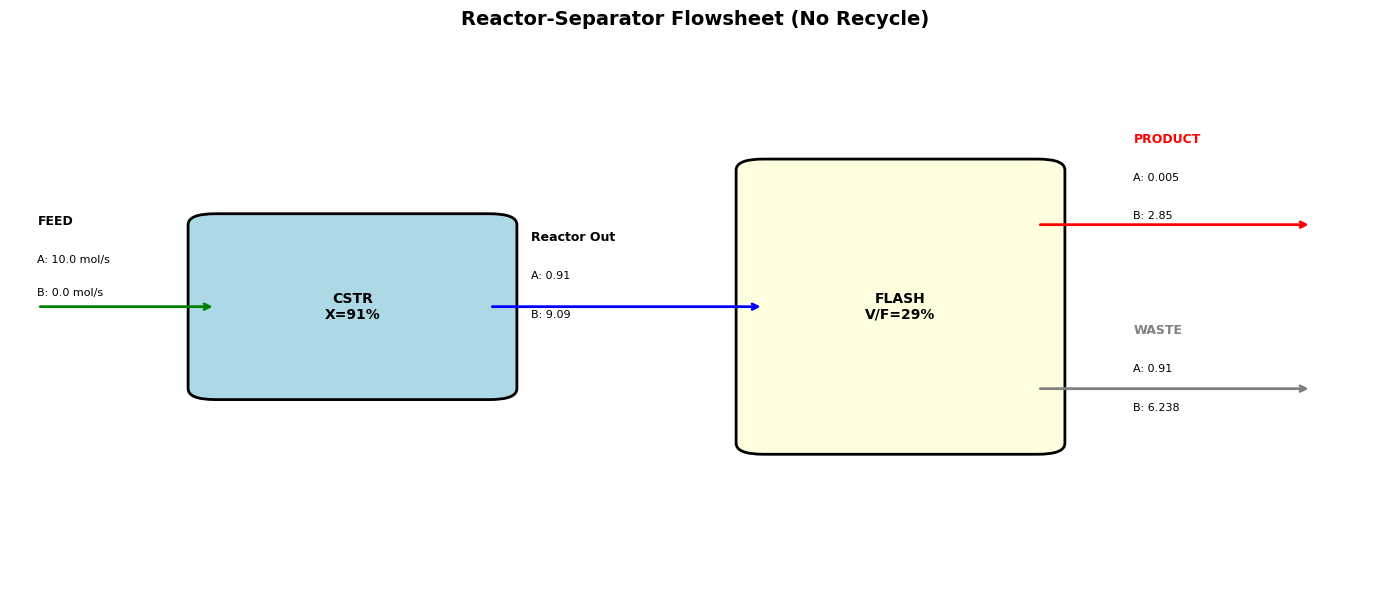

In [8]:
def draw_reactor_separator_flowsheet(feed, reactor_out, liquid, vapor, reactor_conv, vapor_frac):
    fig, ax = plt.subplots(figsize=(14, 6))
    
    # Reactor
    reactor_box = patches.FancyBboxPatch(
        (0.15, 0.35), 0.2, 0.3,
        boxstyle="round,pad=0.02",
        facecolor='lightblue',
        edgecolor='black',
        linewidth=2,
    )
    ax.add_patch(reactor_box)
    ax.text(0.25, 0.5, f'CSTR\nX={reactor_conv*100:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Flash drum
    flash_box = patches.FancyBboxPatch(
        (0.55, 0.25), 0.2, 0.5,
        boxstyle="round,pad=0.02",
        facecolor='lightyellow',
        edgecolor='black',
        linewidth=2,
    )
    ax.add_patch(flash_box)
    ax.text(0.65, 0.5, f'FLASH\nV/F={vapor_frac*100:.0f}%', ha='center', va='center', fontsize=10, fontweight='bold')
    
    # Feed arrow
    ax.annotate('', xy=(0.15, 0.5), xytext=(0.02, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='green'))
    ax.text(0.02, 0.65, 'FEED', fontsize=9, fontweight='bold')
    ax.text(0.02, 0.58, f'A: {float(get_flows(feed)["A"]):.1f} mol/s', fontsize=8)
    ax.text(0.02, 0.52, f'B: {float(get_flows(feed)["B"]):.1f} mol/s', fontsize=8)
    
    # Reactor to Flash
    ax.annotate('', xy=(0.55, 0.5), xytext=(0.35, 0.5),
                arrowprops=dict(arrowstyle='->', lw=2, color='blue'))
    ax.text(0.38, 0.62, 'Reactor Out', fontsize=9, fontweight='bold')
    ax.text(0.38, 0.55, f'A: {float(get_flows(reactor_out)["A"]):.2f}', fontsize=8)
    ax.text(0.38, 0.48, f'B: {float(get_flows(reactor_out)["B"]):.2f}', fontsize=8)
    
    # Vapor product
    ax.annotate('', xy=(0.95, 0.65), xytext=(0.75, 0.65),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
    ax.text(0.82, 0.8, 'PRODUCT', fontsize=9, fontweight='bold', color='red')
    ax.text(0.82, 0.73, f'A: {float(get_flows(vapor)["A"]):.3f}', fontsize=8)
    ax.text(0.82, 0.66, f'B: {float(get_flows(vapor)["B"]):.2f}', fontsize=8)
    
    # Liquid waste
    ax.annotate('', xy=(0.95, 0.35), xytext=(0.75, 0.35),
                arrowprops=dict(arrowstyle='->', lw=2, color='gray'))
    ax.text(0.82, 0.45, 'WASTE', fontsize=9, fontweight='bold', color='gray')
    ax.text(0.82, 0.38, f'A: {float(get_flows(liquid)["A"]):.2f}', fontsize=8)
    ax.text(0.82, 0.31, f'B: {float(get_flows(liquid)["B"]):.3f}', fontsize=8)
    
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')
    ax.set_title('Reactor-Separator Flowsheet (No Recycle)', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    return fig

fig = draw_reactor_separator_flowsheet(
    feed, reactor_out, liquid, vapor,
    float(reactor_info['conversion']['A']),
    float(flash_info['V_frac'])
)


## Making it a Function

Let's wrap the entire flowsheet as a single function. This is the foundation for optimization!

In [9]:
def solve_reactor_separator(params, feed):
    """
    Solve the reactor-separator flowsheet.
    
    Args:
        params: dict with 'V_reactor', 'T_reactor', 'k', 'T_flash', 'P_flash', 'Q_vol'
        feed: Feed stream
    
    Returns:
        dict with all streams and performance metrics
    """
    # Unpack parameters
    V_reactor = params['V_reactor']
    T_reactor = params['T_reactor']
    k = params['k']
    T_flash = params['T_flash']
    P_flash = params.get('P_flash', jnp.array(60000.0))  # 60 kPa for two-phase operation
    Q_vol = params['Q_vol']
    
    # Create reactor
    cstr_p = CSTRParams(
        V=V_reactor,
        rate_fn=rate_fn,
        stoich=stoich,
        rate_params={'k': k},
        species_order=species_order,
    )
    reactor = CSTR(cstr_p, thermo=thermo, mode='isothermal')
    
    # Solve reactor
    reactor_out, reactor_info = reactor(feed, T_spec=float(T_reactor), volumetric_flow=float(Q_vol))
    
    # Solve flash at pressure for good separation
    liquid, vapor, flash_info = flash(reactor_out, T=float(T_flash), P=float(P_flash))
    
    # Calculate metrics
    F_A_feed = get_flows(feed)['A']
    F_B_product = get_flows(vapor)['B']
    
    return {
        'feed': feed,
        'reactor_out': reactor_out,
        'liquid': liquid,
        'vapor': vapor,
        'reactor_conversion': reactor_info['conversion']['A'],
        'vapor_fraction': flash_info['V_frac'],
        'product_B': F_B_product,
        'yield': F_B_product / F_A_feed,
    }

# Test
params = {
    'V_reactor': jnp.array(2.0),
    'T_reactor': jnp.array(350.0),
    'k': jnp.array(0.5),
    'T_flash': jnp.array(350.0),
    'P_flash': jnp.array(60000.0),
    'Q_vol': jnp.array(0.1),
}

result = solve_reactor_separator(params, feed)
print(f"Yield of B: {float(result['yield'])*100:.1f}%")

Yield of B: 28.5%


## Effect of Operating Conditions

Now we can easily explore how parameters affect performance.

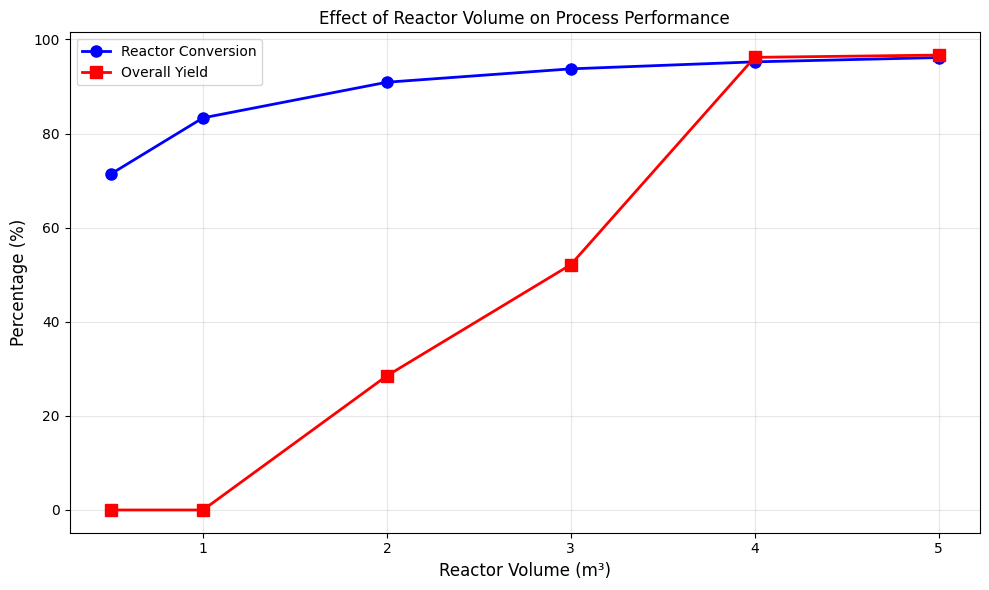

In [10]:
# How does reactor volume affect yield?

volumes = [0.5, 1.0, 2.0, 3.0, 4.0, 5.0]
yields = []
conversions = []

for V in volumes:
    params_test = {
        'V_reactor': jnp.array(V),
        'T_reactor': jnp.array(350.0),
        'k': jnp.array(0.5),
        'T_flash': jnp.array(350.0),
        'P_flash': jnp.array(60000.0),  # 60 kPa for two-phase separation
        'Q_vol': jnp.array(0.1),
    }
    result = solve_reactor_separator(params_test, feed)
    yields.append(float(result['yield']))
    conversions.append(float(result['reactor_conversion']))

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(volumes, [c*100 for c in conversions], 'b-o', linewidth=2, markersize=8, label='Reactor Conversion')
ax.plot(volumes, [y*100 for y in yields], 'r-s', linewidth=2, markersize=8, label='Overall Yield')
ax.set_xlabel('Reactor Volume (m³)', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Effect of Reactor Volume on Process Performance', fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

## Try It Yourself!

### Exercise 1: Temperature Effect
How does flash temperature affect the purity of product B in the vapor stream?

### Exercise 2: Add a Heater
Add a heater between the reactor and flash to increase the flash temperature. Does this improve separation?

### Exercise 3: Multiple Reactors
Replace the single CSTR with two CSTRs in series (each half the original volume). Does this improve conversion?

## End-of-Tutorial Problems

### Problem 1
For the reactor-separator process, calculate the minimum reactor volume needed to achieve 90% overall conversion (not reactor conversion, but process conversion including separation).

### Problem 2
If the unreacted A in the liquid has value (can be sold), at what price does it become better to use a smaller reactor (more waste but lower capital cost)?

### Problem 3
Design a process with a heater between reactor and flash that maximizes yield while keeping flash temperature below 400 K.

---

## Key Takeaways

1. **Stream sharing:** One unit's outlet = another unit's inlet
2. **Sequential solution:** For DAGs, solve units in order
3. **Wrap as function:** Enables parametric studies and optimization
4. **Process metrics:** Overall yield ≠ reactor conversion (separation matters!)

---

## Next Steps

In the next notebook (**[00i: Parallel and Bypass Configurations](./00i_parallel_and_bypass.ipynb)**), we'll explore:
- Splitters and mixers
- Parallel processing paths
- Bypass streams for temperature control